# Bent Lead Detector (single-defect notebook)

Notebook wykrywa tylko bent_lead (good vs bent_lead) na bazie Missing/Extra:
- Missing = M_ref \ M_test
- Extra = M_test \ M_ref

Finalna maska bent: union(Missing, Extra) po cleanup.

## Kolejnosc uruchamiania
1. Run All od gory.
2. W komorce demo zmien test_class i test_name.
3. Uruchom batch eval i diagnostyke.
4. Uruchom tuning progow, potem finalna walidacje.

In [72]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import model

# ===============================
# BENT LEAD - PARAMETRY
# ===============================
LEAD_ZONE_START = 0.68
EROSION_ITERATIONS = 2
MIN_COMPONENT_AREA = 25

# Logika strefowa (analogiczna do cut_lead, ale na Missing+Extra)
MIN_ZONE_MISSING_AREA = 500
MIN_ZONE_EXTRA_AREA = 900
MIN_ZONE_COMBINED_AREA = 2200
DECISION_MODE = "custom_single"  # any | majority | single | custom_single

# Regula single-bent: zwykle 1 wygiety drut
SINGLE_BENT_DOMINANCE_MIN = 0.45
SINGLE_BENT_MIN_COMBINED = 1800

# Regula custom_single: progi strojone pod max F1
CUSTOM_MAX_COMBINED_MIN = 2200
CUSTOM_MAX_MISSING_MIN = 550
CUSTOM_DOMINANCE_MIN = 0.42
CUSTOM_SEPARATION_MAX_RATIO = 0.92
CUSTOM_SHIFT_MAX = 38.0
CUSTOM_SHIFT_OVERRIDE_COMBINED = 4200
CUSTOM_ANGLE_MAX_MIN = 12.0
CUSTOM_ANGLE_SECOND_MAX = 10.0

# Filtr extra: ograniczenie artefaktow o ksztalcie zbyt kolowym
EXTRA_MIN_COMPONENT_AREA = 90
EXTRA_MAX_COMPONENT_CIRCULARITY = 0.58
EXTRA_MIN_COMPONENT_ASPECT = 1.20

# Filtr przestrzenny: zostawiaj extra blisko referencyjnych leadow
USE_NEAR_REF_EXTRA_FILTER = True
EXTRA_NEAR_REF_DILATION = 35

# optional misplaced gate
USE_MISPLACED_GATE = False
MISPLACED_SHIFT_PX = 34.0

# alignment domyslnie OFF dla bent
USE_ALIGNMENT = False

PROJECT_ROOT = Path.cwd()
REFERENCE_MASK = np.load("reference_mask_vote_0.50.npy").astype(np.uint8)

plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['axes.titlesize'] = 10

print("Notebook ustawiony na bent_lead (single-defect, strefy ROI).")

Notebook ustawiony na bent_lead (single-defect, strefy ROI).


In [73]:
def load_rgb(image_path):
    bgr = cv2.imread(str(image_path), cv2.IMREAD_COLOR)
    if bgr is None:
        raise FileNotFoundError(f"Brak obrazu: {image_path}")
    return cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

def cleanup_components(mask, min_area=MIN_COMPONENT_AREA):
    n, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
    out = np.zeros_like(mask)
    for i in range(1, n):
        if int(stats[i, cv2.CC_STAT_AREA]) >= int(min_area):
            out[labels == i] = 255
    return out

def ensure_binary(mask):
    if mask.dtype != np.uint8:
        mask = np.clip(mask, 0, 255).astype(np.uint8)
    return ((mask > 0).astype(np.uint8) * 255)

def filter_extra_components(
    mask,
    min_area=EXTRA_MIN_COMPONENT_AREA,
    max_circularity=EXTRA_MAX_COMPONENT_CIRCULARITY,
    min_aspect=EXTRA_MIN_COMPONENT_ASPECT,
    ):
    binary = ensure_binary(mask)
    n, labels, stats, _ = cv2.connectedComponentsWithStats(binary, connectivity=8)
    out = np.zeros_like(binary)

    for i in range(1, n):
        area = int(stats[i, cv2.CC_STAT_AREA])
        if area < int(min_area):
            continue

        w = int(stats[i, cv2.CC_STAT_WIDTH])
        h = int(stats[i, cv2.CC_STAT_HEIGHT])
        aspect = max(w, h) / float(max(min(w, h), 1))

        comp = (labels == i).astype(np.uint8) * 255
        contours, _ = cv2.findContours(comp, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if not contours:
            continue
        per = cv2.arcLength(contours[0], True)
        if per <= 1e-6:
            continue

        circ = float(4.0 * np.pi * area / (per * per))

        keep = (circ <= float(max_circularity)) or (aspect >= float(min_aspect))
        if keep:
            out[labels == i] = 255

    return out

def keep_extra_near_reference(extra_mask, ref_leads_mask, dilation=EXTRA_NEAR_REF_DILATION):
    extra_b = ensure_binary(extra_mask)
    ref_b = ensure_binary(ref_leads_mask)
    k = int(max(3, dilation))
    if k % 2 == 0:
        k += 1
    kernel = np.ones((k, k), np.uint8)
    ref_support = cv2.dilate(ref_b, kernel, iterations=1)
    return cv2.bitwise_and(extra_b, ref_support)

def zone_angle_from_mask(zone_mask):
    ys, xs = np.where(zone_mask > 0)
    if xs.size < 30:
        return None

    y_top = float(np.percentile(ys, 12))
    y_bottom = float(np.percentile(ys, 92))
    if (y_bottom - y_top) < 4.0:
        return None

    top_sel = ys <= (y_top + 1.5)
    bot_sel = ys >= (y_bottom - 1.5)
    if np.count_nonzero(top_sel) < 3 or np.count_nonzero(bot_sel) < 3:
        return None

    x_top = float(xs[top_sel].mean())
    x_bottom = float(xs[bot_sel].mean())
    dy = float(y_bottom - y_top)
    dx = float(x_bottom - x_top)

    return float(np.degrees(np.arctan2(dx, dy)))

def angle_diff_deg(a, b):
    if a is None or b is None:
        return 0.0
    return float(abs(a - b))

def get_alignment_params(ref_mask, test_mask):
    h, _ = ref_mask.shape
    roi_h = int(h * 0.5)
    ref_top = ref_mask[:roi_h, :]
    test_top = test_mask[:roi_h, :]

    M_ref = cv2.moments(ref_top)
    M_test = cv2.moments(test_top)
    if M_ref['m00'] == 0 or M_test['m00'] == 0:
        return 0, 0

    dx = int(M_ref['m10'] / M_ref['m00'] - M_test['m10'] / M_test['m00'])
    dy = int(M_ref['m01'] / M_ref['m00'] - M_test['m01'] / M_test['m00'])
    return dx, dy

def align_image(mask, dx, dy):
    rows, cols = mask.shape[:2]
    M = np.float32([[1, 0, dx], [0, 1, dy]])
    return cv2.warpAffine(mask, M, (cols, rows), flags=cv2.INTER_NEAREST)

def compute_lead_zones(ref_mask, lead_zone_start=LEAD_ZONE_START):
    ys, xs = np.where(ref_mask > 0)
    if xs.size == 0:
        raise ValueError('Maska referencyjna jest pusta.')

    h, w = ref_mask.shape
    y0 = int(np.clip(int(h * lead_zone_start), 0, h - 1))
    x_min = int(xs.min())
    x_max = int(xs.max())
    if x_max <= x_min:
        raise ValueError('Niepoprawny zakres X maski referencyjnej.')

    width = x_max - x_min + 1
    t1 = x_min + width // 3
    t2 = x_min + (2 * width) // 3

    zones = {
        'left': (x_min, t1),
        'center': (t1, t2),
        'right': (t2, x_max + 1),
    }

    clipped = {}
    for name, (xa, xb) in zones.items():
        xa = int(np.clip(xa, 0, w))
        xb = int(np.clip(xb, 0, w))
        if xb <= xa:
            xb = min(w, xa + 1)
        clipped[name] = (xa, xb)

    return y0, clipped

def extract_core_mask(mask, erosion_ratio=0.04):
    m = ensure_binary(mask)
    h, w = m.shape
    k = int(round(min(h, w) * erosion_ratio))
    k = max(3, min(31, k))
    if k % 2 == 0:
        k += 1
    kernel = np.ones((k, k), np.uint8)
    core = cv2.erode(m, kernel, iterations=1)
    if np.count_nonzero(core) == 0:
        return m
    return core

def centroid(mask):
    ys, xs = np.where(mask > 0)
    if xs.size == 0:
        return None
    return float(xs.mean()), float(ys.mean())

def centroid_distance(mask_a, mask_b):
    ca = centroid(mask_a)
    cb = centroid(mask_b)
    if ca is None or cb is None:
        return 0.0
    return float(np.hypot(ca[0] - cb[0], ca[1] - cb[1]))

In [3]:
def compute_missing_extra_masks(ref_mask, test_mask):
    ref_b = ensure_binary(ref_mask)
    test_b = ensure_binary(test_mask)

    if ref_b.shape != test_b.shape:
        h, w = test_b.shape
        ref_b = cv2.resize(ref_b, (w, h), interpolation=cv2.INTER_NEAREST)

    ref_bin = ref_b > 0
    test_bin = test_b > 0

    missing = np.logical_and(ref_bin, np.logical_not(test_bin)).astype(np.uint8) * 255
    extra = np.logical_and(test_bin, np.logical_not(ref_bin)).astype(np.uint8) * 255

    ref_px = int(np.count_nonzero(ref_bin))
    missing_px = int(np.count_nonzero(missing))
    extra_px = int(np.count_nonzero(extra))

    denom = float(max(ref_px, 1))
    missing_ratio = missing_px / denom
    extra_ratio = extra_px / denom
    total_change_ratio = (missing_px + extra_px) / denom

    return {
        'missing': missing.astype(np.uint8),
        'extra': extra.astype(np.uint8),
        'missing_px': missing_px,
        'extra_px': extra_px,
        'missing_ratio': float(missing_ratio),
        'extra_ratio': float(extra_ratio),
        'total_change_ratio': float(total_change_ratio),
    }

def zone_stats(mask, zones, y0):
    stats = {}
    for zone_name, (x0, x1) in zones.items():
        z = mask[y0:, x0:x1]
        stats[zone_name] = int(np.count_nonzero(z))
    return stats

def zone_dominance(zdict):
    vals = np.array([zdict['left'], zdict['center'], zdict['right']], dtype=np.float32)
    s = float(vals.sum())
    if s <= 0:
        return 0.0
    return float(vals.max() / s)

In [78]:
def detect_bent_lead(
    test_img_rgb,
    ref_mask,
    use_alignment=USE_ALIGNMENT,
    use_misplaced_gate=USE_MISPLACED_GATE,
    misplaced_shift_px=MISPLACED_SHIFT_PX,
    erosion_iterations=EROSION_ITERATIONS,
    min_zone_missing_area=MIN_ZONE_MISSING_AREA,
    min_zone_extra_area=MIN_ZONE_EXTRA_AREA,
    min_zone_combined_area=MIN_ZONE_COMBINED_AREA,
    decision_mode=DECISION_MODE,
    single_bent_dominance_min=SINGLE_BENT_DOMINANCE_MIN,
    single_bent_min_combined=SINGLE_BENT_MIN_COMBINED,
    custom_max_combined_min=CUSTOM_MAX_COMBINED_MIN,
    custom_max_missing_min=CUSTOM_MAX_MISSING_MIN,
    custom_dominance_min=CUSTOM_DOMINANCE_MIN,
    custom_separation_max_ratio=CUSTOM_SEPARATION_MAX_RATIO,
    custom_shift_max=CUSTOM_SHIFT_MAX,
    custom_shift_override_combined=CUSTOM_SHIFT_OVERRIDE_COMBINED,
    custom_angle_max_min=CUSTOM_ANGLE_MAX_MIN,
    custom_angle_second_max=CUSTOM_ANGLE_SECOND_MAX,
    min_component_area=MIN_COMPONENT_AREA,
    extra_min_component_area=EXTRA_MIN_COMPONENT_AREA,
    extra_max_component_circularity=EXTRA_MAX_COMPONENT_CIRCULARITY,
    extra_min_component_aspect=EXTRA_MIN_COMPONENT_ASPECT,
    use_near_ref_extra_filter=USE_NEAR_REF_EXTRA_FILTER,
    extra_near_ref_dilation=EXTRA_NEAR_REF_DILATION,
    return_debug=True,
):
    test_mask = model._extract_transistor_mask(test_img_rgb)
    work_mask = test_mask.copy()

    if use_alignment:
        dx, dy = get_alignment_params(ref_mask, test_mask)
        work_mask = align_image(test_mask, dx, dy)
    else:
        dx, dy = 0, 0

    if work_mask.shape != ref_mask.shape:
        h, w = ref_mask.shape
        work_mask = cv2.resize(work_mask, (w, h), interpolation=cv2.INTER_NEAREST)

    y0, zones = compute_lead_zones(ref_mask, lead_zone_start=LEAD_ZONE_START)

    core_ref = extract_core_mask(ref_mask)
    core_test = extract_core_mask(work_mask)
    shift_px = centroid_distance(core_ref, core_test)

    if use_misplaced_gate and shift_px > float(misplaced_shift_px):
        zero_mask = np.zeros_like(ref_mask, dtype=np.uint8)
        result = {
            'is_bent': False,
            'pred_label': 'not_bent_misplaced_gate',
            'dx': dx,
            'dy': dy,
            'shift_px': float(shift_px),
            'missing_ratio': 0.0,
            'extra_ratio': 0.0,
            'total_change_ratio': 0.0,
            'bent_mask': zero_mask,
            'missing': zero_mask.copy(),
            'extra': zero_mask.copy(),
            'zones': zones,
            'y0': y0,
            'missing_zone': {'left': 0, 'center': 0, 'right': 0},
            'extra_zone': {'left': 0, 'center': 0, 'right': 0},
            'combined_zone': {'left': 0, 'center': 0, 'right': 0},
            'angle_diff_zone': {'left': 0.0, 'center': 0.0, 'right': 0.0},
            'zone_flags': {'left': False, 'center': False, 'right': False},
            'zone_dominance': 0.0,
            'zone_thresholds': {
                'missing': int(min_zone_missing_area),
                'extra': int(min_zone_extra_area),
                'combined': int(min_zone_combined_area),
            },
            'decision_mode': decision_mode,
        }
        if return_debug:
            result['test_mask'] = test_mask
            result['work_mask'] = work_mask
        return result

    kernel = np.ones((3, 3), np.uint8)
    ref_leads = ensure_binary(ref_mask[y0:, :])
    test_leads = ensure_binary(work_mask[y0:, :])

    ref_eroded = cv2.erode(ref_leads, kernel, iterations=int(erosion_iterations))
    test_eroded = cv2.erode(test_leads, kernel, iterations=int(erosion_iterations))

    missing_lead = cv2.subtract(ref_eroded, test_leads)
    extra_lead = cv2.subtract(test_eroded, ref_leads)

    missing_lead = cv2.morphologyEx(missing_lead, cv2.MORPH_OPEN, kernel)
    extra_lead = cv2.morphologyEx(extra_lead, cv2.MORPH_OPEN, kernel)
    missing_lead = cleanup_components(missing_lead, min_area=min_component_area)
    extra_lead = cleanup_components(extra_lead, min_area=min_component_area)
    extra_lead = filter_extra_components(
        extra_lead,
        min_area=extra_min_component_area,
        max_circularity=extra_max_component_circularity,
        min_aspect=extra_min_component_aspect,
    )
    if use_near_ref_extra_filter:
        extra_lead = keep_extra_near_reference(
            extra_lead,
            ref_leads,
            dilation=extra_near_ref_dilation,
        )

    missing = np.zeros_like(ref_mask, dtype=np.uint8)
    extra = np.zeros_like(ref_mask, dtype=np.uint8)
    missing[y0:, :] = missing_lead
    extra[y0:, :] = extra_lead

    missing_zone = {}
    extra_zone = {}
    combined_zone = {}
    angle_diff_zone = {}
    zone_flags = {}

    for zone_name, (x0, x1) in zones.items():
        zm = missing[y0:, x0:x1]
        ze = extra[y0:, x0:x1]
        cm = int(np.count_nonzero(zm))
        ce = int(np.count_nonzero(ze))
        cc = cm + ce

        missing_zone[zone_name] = cm
        extra_zone[zone_name] = ce
        combined_zone[zone_name] = cc

        ref_zone = ref_leads[:, x0:x1]
        test_zone = test_leads[:, x0:x1]
        a_ref = zone_angle_from_mask(ref_zone)
        a_test = zone_angle_from_mask(test_zone)
        angle_diff_zone[zone_name] = angle_diff_deg(a_ref, a_test)

        both_present = (cm >= int(0.6 * min_zone_missing_area)) and (ce >= int(min_zone_extra_area))
        strong_extra = (
            ce >= int(1.5 * min_zone_extra_area) and
            cc >= int(min_zone_combined_area)
        )
        zone_flags[zone_name] = bool((cc >= int(min_zone_combined_area) and both_present) or strong_extra)

    zone_vals = np.array([combined_zone['left'], combined_zone['center'], combined_zone['right']], dtype=np.float32)
    zone_sum = float(zone_vals.sum())
    zone_max = float(zone_vals.max()) if zone_vals.size else 0.0
    zone_second = float(np.partition(zone_vals, -2)[-2]) if zone_vals.size >= 2 else 0.0
    zone_dominance = zone_max / max(zone_sum, 1.0)

    angle_vals = np.array([angle_diff_zone['left'], angle_diff_zone['center'], angle_diff_zone['right']], dtype=np.float32)
    angle_sorted = np.sort(angle_vals)
    angle_max = float(angle_sorted[-1]) if angle_sorted.size else 0.0
    angle_second = float(angle_sorted[-2]) if angle_sorted.size >= 2 else 0.0

    missing_max = max(missing_zone['left'], missing_zone['center'], missing_zone['right'])
    any_flag = bool(zone_flags['left'] or zone_flags['center'] or zone_flags['right'])
    any_signal = zone_max > 0.0

    if decision_mode == "any":
        is_bent = any_flag
    elif decision_mode == "majority":
        is_bent = int(zone_flags['left']) + int(zone_flags['center']) + int(zone_flags['right']) >= 2
    elif decision_mode == "single":
        has_signal = zone_max >= float(single_bent_min_combined)
        dominance_ok = zone_dominance >= float(single_bent_dominance_min)
        separation_ok = zone_second <= 0.85 * zone_max
        is_bent = bool(has_signal and dominance_ok and separation_ok and any_flag)
    elif decision_mode == "custom_single":
        cond_comb = zone_max >= float(custom_max_combined_min)
        cond_miss = missing_max >= float(custom_max_missing_min)
        cond_dom = zone_dominance >= float(custom_dominance_min)
        cond_sep = zone_second <= float(custom_separation_max_ratio) * max(zone_max, 1.0)
        cond_shift = (shift_px <= float(custom_shift_max)) or (zone_max >= float(custom_shift_override_combined))
        cond_angle = (angle_max >= float(custom_angle_max_min)) and (angle_second <= float(custom_angle_second_max))
        is_bent = bool(any_signal and cond_comb and cond_miss and cond_dom and cond_sep and cond_shift and cond_angle)
    else:
        raise ValueError(f"Nieobslugiwany decision_mode: {decision_mode}")

    bent_mask = cv2.bitwise_or(missing, extra)
    support = cv2.bitwise_or(ensure_binary(ref_mask), ensure_binary(work_mask))
    support = cv2.dilate(support, np.ones((9, 9), np.uint8), iterations=1)
    bent_mask = cv2.bitwise_and(bent_mask, support)
    bent_mask = cv2.morphologyEx(bent_mask, cv2.MORPH_OPEN, np.ones((3, 3), np.uint8), iterations=1)
    bent_mask = cleanup_components(bent_mask, min_area=min_component_area).astype(np.uint8)

    if not is_bent:
        bent_mask = np.zeros_like(bent_mask, dtype=np.uint8)

    ref_px = int(np.count_nonzero(ensure_binary(ref_mask)))
    missing_px = int(np.count_nonzero(missing))
    extra_px = int(np.count_nonzero(extra))
    denom = float(max(ref_px, 1))

    result = {
        'is_bent': bool(is_bent),
        'pred_label': 'bent_lead' if is_bent else 'good_or_other',
        'dx': dx,
        'dy': dy,
        'shift_px': float(shift_px),
        'missing_ratio': float(missing_px / denom),
        'extra_ratio': float(extra_px / denom),
        'total_change_ratio': float((missing_px + extra_px) / denom),
        'missing_px': missing_px,
        'extra_px': extra_px,
        'bent_mask': bent_mask,
        'missing': missing,
        'extra': extra,
        'zones': zones,
        'y0': y0,
        'missing_zone': missing_zone,
        'extra_zone': extra_zone,
        'combined_zone': combined_zone,
        'angle_diff_zone': angle_diff_zone,
        'angle_max': angle_max,
        'angle_second': angle_second,
        'zone_flags': zone_flags,
        'zone_dominance': float(zone_dominance),
        'zone_thresholds': {
            'missing': int(min_zone_missing_area),
            'extra': int(min_zone_extra_area),
            'combined': int(min_zone_combined_area),
        },
        'decision_mode': decision_mode,
    }

    if return_debug:
        result['test_mask'] = test_mask
        result['work_mask'] = work_mask

    return result

In [14]:
def _draw_zone_lines(ax, y0, zones):
    colors = {'left': 'lime', 'center': 'cyan', 'right': 'yellow'}
    for zone_name, (x0, x1) in zones.items():
        ax.axvline(x=x0, color=colors[zone_name], linestyle='--', linewidth=1)
        ax.axvline(x=x1, color=colors[zone_name], linestyle='--', linewidth=1)
    ax.axhline(y=y0, color='orange', linestyle=':', linewidth=1)

def print_bent_table(result):
    print('Bent Summary')
    print(f"  pred_label={result['pred_label']} | is_bent={result['is_bent']}")
    print(f"  missing_ratio={result['missing_ratio']:.4f} extra_ratio={result['extra_ratio']:.4f} total={result['total_change_ratio']:.4f}")
    print(f"  shift_px={result['shift_px']:.2f} | decision_mode={result['decision_mode']}")
    zthr = result['zone_thresholds']
    print(f"  thresholds: missing>={zthr['missing']} extra>={zthr['extra']} combined>={zthr['combined']}")
    for z in ['left', 'center', 'right']:
        print(
            f"  {z:6s} | missing={result['missing_zone'][z]:5d} | "
            f"extra={result['extra_zone'][z]:5d} | combined={result['combined_zone'][z]:5d} | "
            f"flag={result['zone_flags'][z]}"
        )

def visualize_bent_result(img_rgb, ref_mask, result):
    y0 = result['y0']
    zones = result['zones']

    fig, axes = plt.subplots(2, 4, figsize=(18, 9))

    axes[0, 0].imshow(img_rgb)
    axes[0, 0].set_title(f"Orig | {result['pred_label']}")
    axes[0, 0].axis('off')

    axes[0, 1].imshow(ref_mask, cmap='gray')
    _draw_zone_lines(axes[0, 1], y0, zones)
    axes[0, 1].set_title('Reference mask + zones')
    axes[0, 1].axis('off')

    axes[0, 2].imshow(result['work_mask'], cmap='gray')
    _draw_zone_lines(axes[0, 2], y0, zones)
    axes[0, 2].set_title('Test mask (work)')
    axes[0, 2].axis('off')

    axes[0, 3].imshow(result['bent_mask'], cmap='hot')
    _draw_zone_lines(axes[0, 3], y0, zones)
    axes[0, 3].set_title('Final bent mask')
    axes[0, 3].axis('off')

    axes[1, 0].imshow(result['missing'], cmap='hot')
    _draw_zone_lines(axes[1, 0], y0, zones)
    axes[1, 0].set_title('Missing')
    axes[1, 0].axis('off')

    axes[1, 1].imshow(result['extra'], cmap='hot')
    _draw_zone_lines(axes[1, 1], y0, zones)
    axes[1, 1].set_title('Extra')
    axes[1, 1].axis('off')

    for i, zone_name in enumerate(['left', 'center', 'right']):
        x0, x1 = zones[zone_name]
        zmiss = result['missing'][y0:, x0:x1]
        zextra = result['extra'][y0:, x0:x1]
        z = cv2.bitwise_or(zmiss, zextra)
        ax = axes[1, i+1] if i < 2 else axes[1, 3]
        ax.imshow(z, cmap='hot')
        ax.set_title(
            f"{zone_name}: M={result['missing_zone'][zone_name]} "
            f"E={result['extra_zone'][zone_name]} C={result['combined_zone'][zone_name]} "
            f"F={result['zone_flags'][zone_name]}"
        )
        ax.axis('off')

    plt.tight_layout()
    plt.show()

Plik: 008.png | Klasa folderu: bent_lead
Bent Summary
  pred_label=good_or_other | is_bent=False
  missing_ratio=0.0185 extra_ratio=0.0114 total=0.0299
  shift_px=21.58 | decision_mode=majority
  thresholds: missing>=500 extra>=900 combined>=2200
  left   | missing=  601 | extra= 1780 | combined= 2381 | flag=True
  center | missing= 3351 | extra=  151 | combined= 3502 | flag=False
  right  | missing=  673 | extra=  911 | combined= 1584 | flag=False


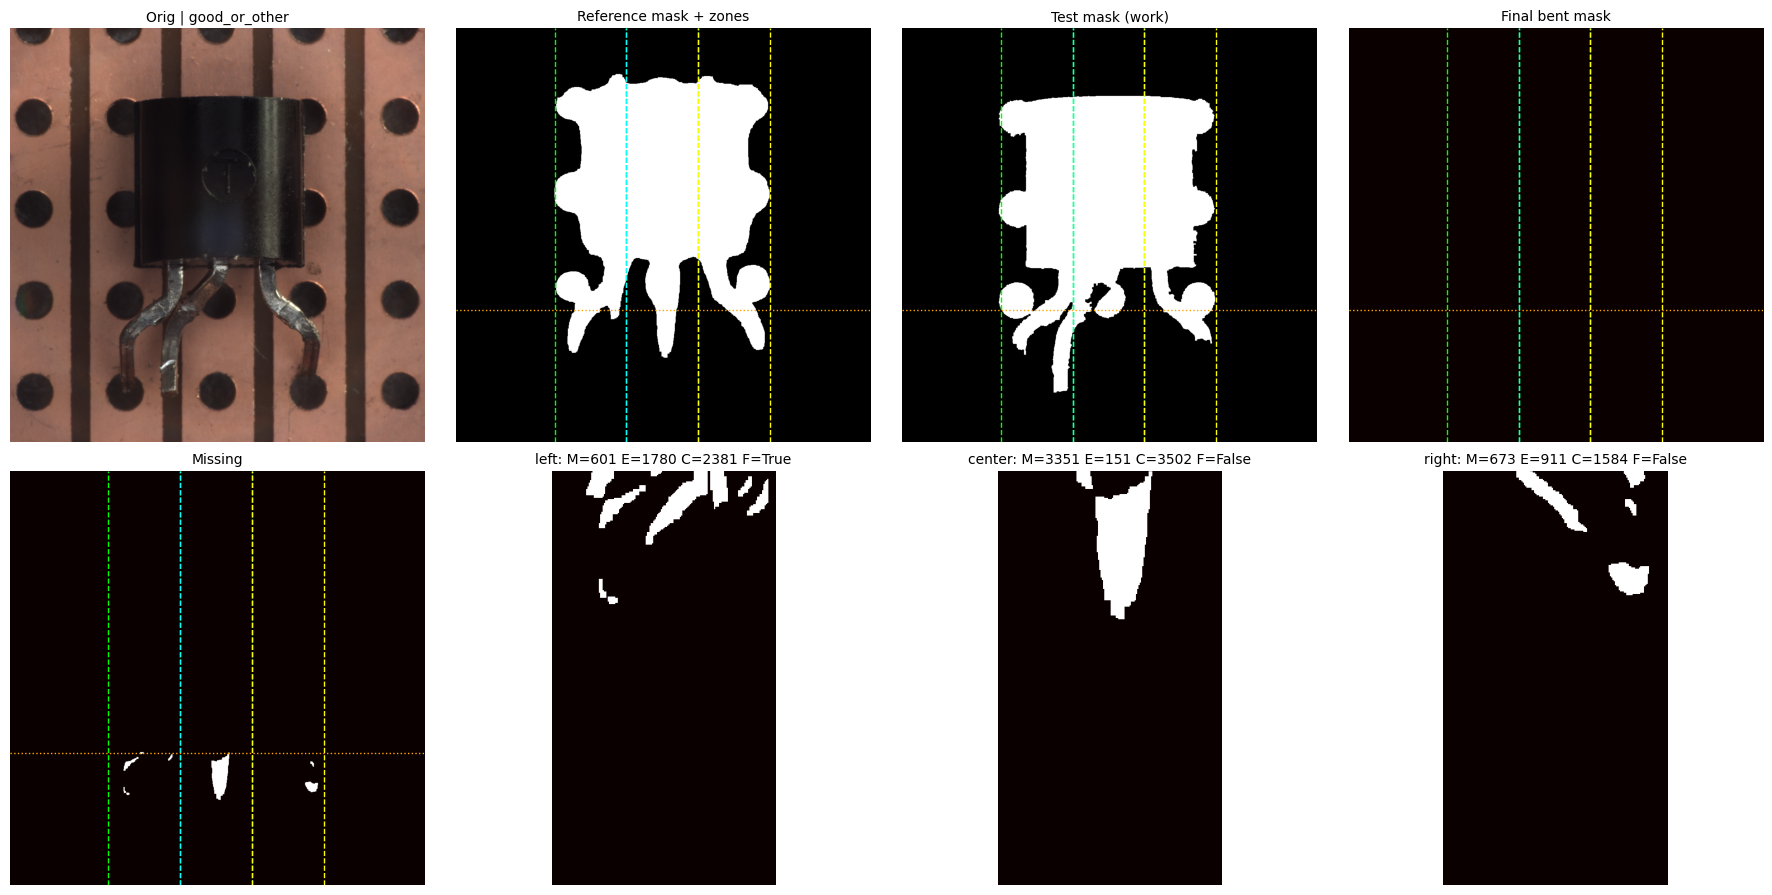

In [53]:
# DEMO: pojedynczy obraz
test_class = 'bent_lead'   # np. good / bent_lead / cut_lead / misplaced
test_name = '008.png'

test_path = PROJECT_ROOT / 'transistor' / 'test' / test_class / test_name
test_img = load_rgb(test_path)

demo_result = detect_bent_lead(
    test_img,
    REFERENCE_MASK,
    use_alignment=USE_ALIGNMENT,
    use_misplaced_gate=USE_MISPLACED_GATE,
    return_debug=True,
)

print(f"Plik: {test_path.name} | Klasa folderu: {test_class}")
print_bent_table(demo_result)
visualize_bent_result(test_img, REFERENCE_MASK, demo_result)

In [75]:
# BATCH EVAL: bent_lead vs reszta
def iter_class_files(class_name):
    folder = PROJECT_ROOT / 'transistor' / 'test' / class_name
    return sorted(folder.glob('*.png'))

def evaluate_bent(all_classes=None, limits=None, config=None):
    if all_classes is None:
        all_classes = ['good', 'bent_lead', 'cut_lead', 'damaged_case', 'misplaced']

    if limits is None:
        limits = {}

    if config is None:
        config = {
            'erosion_iterations': EROSION_ITERATIONS,
            'min_zone_missing_area': MIN_ZONE_MISSING_AREA,
            'min_zone_extra_area': MIN_ZONE_EXTRA_AREA,
            'min_zone_combined_area': MIN_ZONE_COMBINED_AREA,
            'decision_mode': DECISION_MODE,
            'single_bent_dominance_min': SINGLE_BENT_DOMINANCE_MIN,
            'single_bent_min_combined': SINGLE_BENT_MIN_COMBINED,
            'custom_max_combined_min': CUSTOM_MAX_COMBINED_MIN,
            'custom_max_missing_min': CUSTOM_MAX_MISSING_MIN,
            'custom_dominance_min': CUSTOM_DOMINANCE_MIN,
            'custom_separation_max_ratio': CUSTOM_SEPARATION_MAX_RATIO,
            'custom_shift_max': CUSTOM_SHIFT_MAX,
            'custom_shift_override_combined': CUSTOM_SHIFT_OVERRIDE_COMBINED,
            'custom_angle_max_min': CUSTOM_ANGLE_MAX_MIN,
            'custom_angle_second_max': CUSTOM_ANGLE_SECOND_MAX,
            'use_alignment': USE_ALIGNMENT,
            'use_misplaced_gate': USE_MISPLACED_GATE,
            'misplaced_shift_px': MISPLACED_SHIFT_PX,
            'min_component_area': MIN_COMPONENT_AREA,
            'use_near_ref_extra_filter': USE_NEAR_REF_EXTRA_FILTER,
            'extra_near_ref_dilation': EXTRA_NEAR_REF_DILATION,
        }

    rows = []
    for class_name in all_classes:
        files = iter_class_files(class_name)
        lim = limits.get(class_name)
        if lim is not None:
            files = files[:lim]

        for p in files:
            img = load_rgb(p)
            res = detect_bent_lead(
                img,
                REFERENCE_MASK,
                use_alignment=config['use_alignment'],
                use_misplaced_gate=config['use_misplaced_gate'],
                misplaced_shift_px=config['misplaced_shift_px'],
                erosion_iterations=config['erosion_iterations'],
                min_zone_missing_area=config['min_zone_missing_area'],
                min_zone_extra_area=config['min_zone_extra_area'],
                min_zone_combined_area=config['min_zone_combined_area'],
                decision_mode=config['decision_mode'],
                single_bent_dominance_min=config.get('single_bent_dominance_min', SINGLE_BENT_DOMINANCE_MIN),
                single_bent_min_combined=config.get('single_bent_min_combined', SINGLE_BENT_MIN_COMBINED),
                custom_max_combined_min=config.get('custom_max_combined_min', CUSTOM_MAX_COMBINED_MIN),
                custom_max_missing_min=config.get('custom_max_missing_min', CUSTOM_MAX_MISSING_MIN),
                custom_dominance_min=config.get('custom_dominance_min', CUSTOM_DOMINANCE_MIN),
                custom_separation_max_ratio=config.get('custom_separation_max_ratio', CUSTOM_SEPARATION_MAX_RATIO),
                custom_shift_max=config.get('custom_shift_max', CUSTOM_SHIFT_MAX),
                custom_shift_override_combined=config.get('custom_shift_override_combined', CUSTOM_SHIFT_OVERRIDE_COMBINED),
                custom_angle_max_min=config.get('custom_angle_max_min', CUSTOM_ANGLE_MAX_MIN),
                custom_angle_second_max=config.get('custom_angle_second_max', CUSTOM_ANGLE_SECOND_MAX),
                min_component_area=config['min_component_area'],
                use_near_ref_extra_filter=config.get('use_near_ref_extra_filter', USE_NEAR_REF_EXTRA_FILTER),
                extra_near_ref_dilation=config.get('extra_near_ref_dilation', EXTRA_NEAR_REF_DILATION),
                return_debug=False,
            )

            rows.append({
                'class_name': class_name,
                'file_name': p.name,
                'pred': bool(res['is_bent']),
                'gt': class_name == 'bent_lead',
                'pred_label': res['pred_label'],
                'missing_ratio': res['missing_ratio'],
                'extra_ratio': res['extra_ratio'],
                'total_change_ratio': res['total_change_ratio'],
                'shift_px': res['shift_px'],
                'left_flag': res['zone_flags']['left'],
                'center_flag': res['zone_flags']['center'],
                'right_flag': res['zone_flags']['right'],
                'left_combined': res['combined_zone']['left'],
                'center_combined': res['combined_zone']['center'],
                'right_combined': res['combined_zone']['right'],
                'left_missing': res['missing_zone']['left'],
                'center_missing': res['missing_zone']['center'],
                'right_missing': res['missing_zone']['right'],
                'left_angle_diff': res['angle_diff_zone']['left'],
                'center_angle_diff': res['angle_diff_zone']['center'],
                'right_angle_diff': res['angle_diff_zone']['right'],
                'angle_max': res.get('angle_max', 0.0),
                'angle_second': res.get('angle_second', 0.0),
                'zone_dominance': res.get('zone_dominance', 0.0),
            })

    return rows

def summarize_rows(rows, verbose=True):
    tp = sum(1 for r in rows if r['gt'] and r['pred'])
    tn = sum(1 for r in rows if (not r['gt']) and (not r['pred']))
    fp = sum(1 for r in rows if (not r['gt']) and r['pred'])
    fn = sum(1 for r in rows if r['gt'] and (not r['pred']))

    precision = tp / max(tp + fp, 1)
    recall = tp / max(tp + fn, 1)
    tnr = tn / max(tn + fp, 1)
    f1 = 2 * precision * recall / max(precision + recall, 1e-9)
    balanced = 0.5 * (recall + tnr)

    if verbose:
        print(f"TP={tp} TN={tn} FP={fp} FN={fn}")
        print(f"precision={precision:.3f} recall={recall:.3f} tnr={tnr:.3f} f1={f1:.3f} balanced={balanced:.3f}")

    return {
        'tp': tp, 'tn': tn, 'fp': fp, 'fn': fn,
        'precision': precision, 'recall': recall, 'tnr': tnr,
        'f1': f1, 'balanced': balanced,
    }

rows_quick = evaluate_bent(limits={'good': 20})
metrics_quick = summarize_rows(rows_quick, verbose=True)

TP=0 TN=41 FP=6 FN=9
precision=0.000 recall=0.000 tnr=0.872 f1=0.000 balanced=0.436


In [24]:
# DIAGNOSTYKA + GRID SEARCH (strefowy, podobny stylem do cut_lead)
def print_feature_stats(rows):
    for cls in ['good', 'bent_lead', 'cut_lead', 'damaged_case', 'misplaced']:
        subset = [r for r in rows if r['class_name'] == cls]
        if not subset:
            continue
        mr = np.array([r['missing_ratio'] for r in subset], dtype=np.float32)
        er = np.array([r['extra_ratio'] for r in subset], dtype=np.float32)
        tr = np.array([r['total_change_ratio'] for r in subset], dtype=np.float32)
        print(f"\nKlasa={cls}")
        print(f"  missing  min={mr.min():.4f} max={mr.max():.4f} mean={mr.mean():.4f}")
        print(f"  extra    min={er.min():.4f} max={er.max():.4f} mean={er.mean():.4f}")
        print(f"  total    min={tr.min():.4f} max={tr.max():.4f} mean={tr.mean():.4f}")

def grid_search_bent(limits=None):
    if limits is None:
        limits = {'good': 25}

    miss_vals = [400, 500, 700]
    extra_vals = [700, 900, 1200]
    comb_vals = [1800, 2200, 3000]

    out = []
    total_cfg = len(miss_vals) * len(extra_vals) * len(comb_vals)
    i = 0

    for mthr in miss_vals:
        for ethr in extra_vals:
            for cthr in comb_vals:
                i += 1
                cfg = {
                    'erosion_iterations': EROSION_ITERATIONS,
                    'min_zone_missing_area': mthr,
                    'min_zone_extra_area': ethr,
                    'min_zone_combined_area': cthr,
                    'decision_mode': DECISION_MODE,
                    'use_alignment': USE_ALIGNMENT,
                    'use_misplaced_gate': USE_MISPLACED_GATE,
                    'misplaced_shift_px': MISPLACED_SHIFT_PX,
                    'min_component_area': MIN_COMPONENT_AREA,
                }

                rows = evaluate_bent(config=cfg, limits=limits)
                m = summarize_rows(rows, verbose=False)

                fp_good = sum(1 for r in rows if r['class_name'] == 'good' and r['pred'])
                out.append({
                    'min_zone_missing_area': mthr,
                    'min_zone_extra_area': ethr,
                    'min_zone_combined_area': cthr,
                    'f1': m['f1'],
                    'balanced': m['balanced'],
                    'precision': m['precision'],
                    'recall': m['recall'],
                    'fp_good': fp_good,
                    'fp': m['fp'],
                    'fn': m['fn'],
                })

                if i % 5 == 0 or i == total_cfg:
                    print(f"Progress: {i}/{total_cfg}")

    out = sorted(out, key=lambda r: (r['f1'], r['balanced'], -r['fp_good']), reverse=True)
    print('Top 10 config:')
    for r in out[:10]:
        print(r)
    return out

print_feature_stats(rows_quick)
grid_results = grid_search_bent()
best_config = grid_results[0]
print('\nBest config:', best_config)


Klasa=good
  missing  min=0.0000 max=0.0199 mean=0.0067
  extra    min=0.0000 max=0.0367 mean=0.0069
  total    min=0.0000 max=0.0543 mean=0.0136

Klasa=bent_lead
  missing  min=0.0000 max=0.0294 mean=0.0092
  extra    min=0.0000 max=0.0417 mean=0.0130
  total    min=0.0000 max=0.0602 mean=0.0221

Klasa=cut_lead
  missing  min=0.0000 max=0.0000 mean=0.0000
  extra    min=0.0000 max=0.0000 mean=0.0000
  total    min=0.0000 max=0.0000 mean=0.0000

Klasa=damaged_case
  missing  min=0.0000 max=0.0250 mean=0.0071
  extra    min=0.0000 max=0.0223 mean=0.0048
  total    min=0.0000 max=0.0474 mean=0.0120

Klasa=misplaced
  missing  min=0.0000 max=0.0494 mean=0.0110
  extra    min=0.0000 max=0.0000 mean=0.0000
  total    min=0.0000 max=0.0494 mean=0.0110
Progress: 5/27
Progress: 10/27
Progress: 15/27
Progress: 20/27
Progress: 25/27
Progress: 27/27
Top 10 config:
{'min_zone_missing_area': 400, 'min_zone_extra_area': 700, 'min_zone_combined_area': 3000, 'f1': 0.26666666666666666, 'balanced': 0.5

TP=0 TN=74 FP=3 FN=9
precision=0.000 recall=0.000 tnr=0.961 f1=0.000 balanced=0.481

False positives: ['good/033.png', 'good/048.png', 'damaged_case/006.png']
False negatives: ['bent_lead/000.png', 'bent_lead/001.png', 'bent_lead/002.png', 'bent_lead/003.png', 'bent_lead/004.png', 'bent_lead/005.png', 'bent_lead/006.png', 'bent_lead/007.png', 'bent_lead/008.png']

Ustaw te wartosci jako default na gorze notebooka:
{'erosion_iterations': 2, 'min_zone_missing_area': 400, 'min_zone_extra_area': 700, 'min_zone_combined_area': 3000, 'decision_mode': 'majority', 'use_alignment': False, 'use_misplaced_gate': True, 'misplaced_shift_px': 22.0, 'min_component_area': 25, 'use_near_ref_extra_filter': True, 'extra_near_ref_dilation': 23}
Plik: 003.png
Sciezka: c:\Coding\Sem_6\ZAW\CWP\Transformers\proj01\transistor\test\bent_lead\003.png
Predykcja: good_or_other
Bent Summary
  pred_label=good_or_other | is_bent=False
  missing_ratio=0.0185 extra_ratio=0.0105 total=0.0291
  shift_px=18.48 | decision_

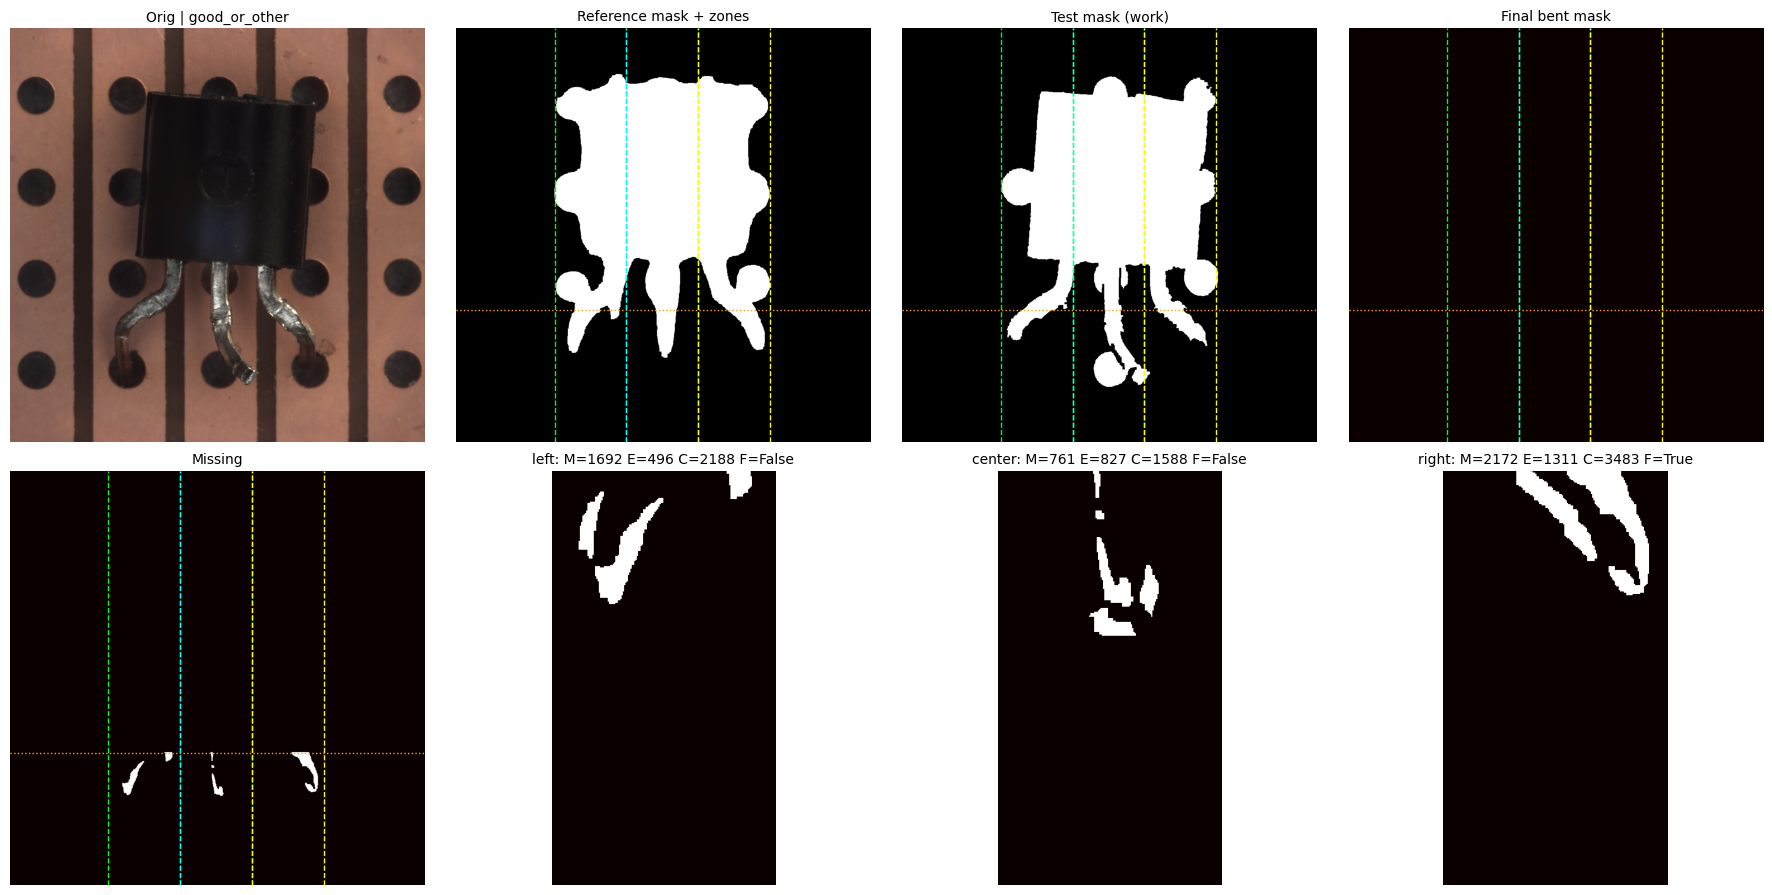

In [ ]:
# FINALNA WALIDACJA + klasyfikacja 1 pliku
final_cfg = {
    'erosion_iterations': EROSION_ITERATIONS,
    'min_zone_missing_area': best_config['min_zone_missing_area'],
    'min_zone_extra_area': best_config['min_zone_extra_area'],
    'min_zone_combined_area': best_config['min_zone_combined_area'],
    'decision_mode': DECISION_MODE,
    'single_bent_dominance_min': SINGLE_BENT_DOMINANCE_MIN,
    'single_bent_min_combined': SINGLE_BENT_MIN_COMBINED,
    'custom_max_combined_min': CUSTOM_MAX_COMBINED_MIN,
    'custom_max_missing_min': CUSTOM_MAX_MISSING_MIN,
    'custom_dominance_min': CUSTOM_DOMINANCE_MIN,
    'custom_separation_max_ratio': CUSTOM_SEPARATION_MAX_RATIO,
    'custom_shift_max': CUSTOM_SHIFT_MAX,
    'custom_shift_override_combined': CUSTOM_SHIFT_OVERRIDE_COMBINED,
    'custom_angle_max_min': CUSTOM_ANGLE_MAX_MIN,
    'custom_angle_second_max': CUSTOM_ANGLE_SECOND_MAX,
    'use_alignment': USE_ALIGNMENT,
    'use_misplaced_gate': USE_MISPLACED_GATE,
    'misplaced_shift_px': MISPLACED_SHIFT_PX,
    'min_component_area': MIN_COMPONENT_AREA,
    'use_near_ref_extra_filter': USE_NEAR_REF_EXTRA_FILTER,
    'extra_near_ref_dilation': EXTRA_NEAR_REF_DILATION,
}

rows_final = evaluate_bent(config=final_cfg)
metrics_final = summarize_rows(rows_final, verbose=True)

fp_files = [f"{r['class_name']}/{r['file_name']}" for r in rows_final if (not r['gt']) and r['pred']]
fn_files = [f"{r['class_name']}/{r['file_name']}" for r in rows_final if r['gt'] and (not r['pred'])]

print('\nFalse positives:', fp_files if fp_files else 'brak')
print('False negatives:', fn_files if fn_files else 'brak')
print('\nUstaw te wartosci jako default na gorze notebooka:')
print(final_cfg)

DEFAULT_CLASSIFY_CFG = final_cfg.copy()

def resolve_input_image(file_name, class_name=None):
    direct = Path(file_name)
    if direct.exists():
        return direct

    test_root = PROJECT_ROOT / 'transistor' / 'test'
    if class_name is not None:
        candidate = test_root / class_name / file_name
        if candidate.exists():
            return candidate
        raise FileNotFoundError(f"Nie znaleziono pliku: {candidate}")

    matches = sorted(test_root.glob(f"**/{file_name}"))
    if not matches:
        raise FileNotFoundError(f"Nie znaleziono pliku {file_name} w {test_root}")
    if len(matches) > 1:
        print('Uwaga: wiele plikow o tej nazwie, uzywam pierwszego:')
        for m in matches:
            print(f"  - {m.relative_to(test_root)}")
    return matches[0]

def classify_one_image(file_name, class_name=None, config=None, show_plot=True):
    if config is None:
        config = DEFAULT_CLASSIFY_CFG

    image_path = resolve_input_image(file_name, class_name=class_name)
    img = load_rgb(image_path)

    res = detect_bent_lead(
        img,
        REFERENCE_MASK,
        use_alignment=config['use_alignment'],
        use_misplaced_gate=config['use_misplaced_gate'],
        misplaced_shift_px=config['misplaced_shift_px'],
        erosion_iterations=config['erosion_iterations'],
        min_zone_missing_area=config['min_zone_missing_area'],
        min_zone_extra_area=config['min_zone_extra_area'],
        min_zone_combined_area=config['min_zone_combined_area'],
        decision_mode=config['decision_mode'],
        single_bent_dominance_min=config.get('single_bent_dominance_min', SINGLE_BENT_DOMINANCE_MIN),
        single_bent_min_combined=config.get('single_bent_min_combined', SINGLE_BENT_MIN_COMBINED),
        custom_max_combined_min=config.get('custom_max_combined_min', CUSTOM_MAX_COMBINED_MIN),
        custom_max_missing_min=config.get('custom_max_missing_min', CUSTOM_MAX_MISSING_MIN),
        custom_dominance_min=config.get('custom_dominance_min', CUSTOM_DOMINANCE_MIN),
        custom_separation_max_ratio=config.get('custom_separation_max_ratio', CUSTOM_SEPARATION_MAX_RATIO),
        custom_shift_max=config.get('custom_shift_max', CUSTOM_SHIFT_MAX),
        custom_shift_override_combined=config.get('custom_shift_override_combined', CUSTOM_SHIFT_OVERRIDE_COMBINED),
        custom_angle_max_min=config.get('custom_angle_max_min', CUSTOM_ANGLE_MAX_MIN),
        custom_angle_second_max=config.get('custom_angle_second_max', CUSTOM_ANGLE_SECOND_MAX),
        min_component_area=config['min_component_area'],
        use_near_ref_extra_filter=config.get('use_near_ref_extra_filter', USE_NEAR_REF_EXTRA_FILTER),
        extra_near_ref_dilation=config.get('extra_near_ref_dilation', EXTRA_NEAR_REF_DILATION),
        return_debug=True,
    )

    print(f"Plik: {image_path.name}")
    print(f"Sciezka: {image_path}")
    print(f"Predykcja: {res['pred_label']}")
    print_bent_table(res)

    if show_plot:
        visualize_bent_result(img, REFERENCE_MASK, res)

    return res['pred_label'], res

# Przyklad:
pred_label, pred_result = classify_one_image('003.png', class_name='bent_lead')

In [79]:
# MINI-SWEEP FAST CACHE: custom_single + angle pod max F1
base_cfg = final_cfg.copy()

def metrics_from_preds(rows, preds):
    tp = sum(1 for r, p in zip(rows, preds) if r['gt'] and p)
    tn = sum(1 for r, p in zip(rows, preds) if (not r['gt']) and (not p))
    fp = sum(1 for r, p in zip(rows, preds) if (not r['gt']) and p)
    fn = sum(1 for r, p in zip(rows, preds) if r['gt'] and (not p))
    precision = tp / max(tp + fp, 1)
    recall = tp / max(tp + fn, 1)
    tnr = tn / max(tn + fp, 1)
    f1 = 2 * precision * recall / max(precision + recall, 1e-9)
    balanced = 0.5 * (recall + tnr)
    fp_good = sum(1 for r, p in zip(rows, preds) if r['class_name'] == 'good' and p)
    return {
        'tp': tp, 'tn': tn, 'fp': fp, 'fn': fn,
        'precision': precision, 'recall': recall, 'tnr': tnr,
        'f1': f1, 'balanced': balanced, 'fp_good': fp_good,
    }

cached_sets = []
for near_ref in [True, False]:
    for dil in [27, 35, 43]:
        cfg = base_cfg.copy()
        cfg['decision_mode'] = 'any'
        cfg['use_near_ref_extra_filter'] = near_ref
        cfg['extra_near_ref_dilation'] = dil
        cfg['use_misplaced_gate'] = False
        rows = evaluate_bent(config=cfg)
        cached_sets.append({'near_ref': near_ref, 'dil': dil, 'rows': rows})
        print(f"Cached rows: near_ref={near_ref}, dil={dil}, n={len(rows)}")

search = []
for cache_item in cached_sets:
    rows = cache_item['rows']
    for comb_thr in [1400, 1800, 2200, 2600, 3000]:
        for miss_thr in [200, 400, 600, 800]:
            for dom_thr in [0.30, 0.38, 0.46, 0.54]:
                for sep_ratio in [0.80, 0.90, 1.00]:
                    for shift_thr in [26.0, 34.0, 42.0, 60.0]:
                        for shift_override in [3200, 4200, 5200]:
                            for angle_max_thr in [8.0, 12.0, 16.0, 20.0]:
                                for angle_second_thr in [6.0, 10.0, 14.0]:
                                    preds = []
                                    for r in rows:
                                        z = np.array([r['left_combined'], r['center_combined'], r['right_combined']], dtype=np.float32)
                                        z_sorted = np.sort(z)
                                        z_max = float(z_sorted[-1])
                                        z_second = float(z_sorted[-2]) if z_sorted.size >= 2 else 0.0
                                        z_sum = float(z.sum())
                                        dom = z_max / max(z_sum, 1.0)

                                        m_max = max(r['left_missing'], r['center_missing'], r['right_missing'])
                                        any_signal = z_max > 0.0

                                        cond_comb = z_max >= comb_thr
                                        cond_miss = m_max >= miss_thr
                                        cond_dom = dom >= dom_thr
                                        cond_sep = z_second <= sep_ratio * max(z_max, 1.0)
                                        cond_shift = (r['shift_px'] <= shift_thr) or (z_max >= shift_override)
                                        cond_angle = (r['angle_max'] >= angle_max_thr) and (r['angle_second'] <= angle_second_thr)

                                        pred = bool(any_signal and cond_comb and cond_miss and cond_dom and cond_sep and cond_shift and cond_angle)
                                        preds.append(pred)

                                    m = metrics_from_preds(rows, preds)
                                    search.append({
                                        'use_near_ref_extra_filter': cache_item['near_ref'],
                                        'extra_near_ref_dilation': cache_item['dil'],
                                        'custom_max_combined_min': comb_thr,
                                        'custom_max_missing_min': miss_thr,
                                        'custom_dominance_min': dom_thr,
                                        'custom_separation_max_ratio': sep_ratio,
                                        'custom_shift_max': shift_thr,
                                        'custom_shift_override_combined': shift_override,
                                        'custom_angle_max_min': angle_max_thr,
                                        'custom_angle_second_max': angle_second_thr,
                                        'tp': m['tp'],
                                        'fp': m['fp'],
                                        'fn': m['fn'],
                                        'f1': m['f1'],
                                        'precision': m['precision'],
                                        'recall': m['recall'],
                                        'balanced': m['balanced'],
                                        'fp_good': m['fp_good'],
                                    })

search = sorted(search, key=lambda r: (r['f1'], r['precision'], r['balanced'], -r['fp_good']), reverse=True)
print('TOP 10 custom_single+angle sweep:')
for row in search[:10]:
    print(row)

best_fast = search[0]
print('\nBEST FAST:', best_fast)

final_cfg['decision_mode'] = 'custom_single'
final_cfg['use_near_ref_extra_filter'] = best_fast['use_near_ref_extra_filter']
final_cfg['extra_near_ref_dilation'] = best_fast['extra_near_ref_dilation']
final_cfg['use_misplaced_gate'] = False
final_cfg['custom_max_combined_min'] = best_fast['custom_max_combined_min']
final_cfg['custom_max_missing_min'] = best_fast['custom_max_missing_min']
final_cfg['custom_dominance_min'] = best_fast['custom_dominance_min']
final_cfg['custom_separation_max_ratio'] = best_fast['custom_separation_max_ratio']
final_cfg['custom_shift_max'] = best_fast['custom_shift_max']
final_cfg['custom_shift_override_combined'] = best_fast['custom_shift_override_combined']
final_cfg['custom_angle_max_min'] = best_fast['custom_angle_max_min']
final_cfg['custom_angle_second_max'] = best_fast['custom_angle_second_max']

rows_diag = evaluate_bent(config=final_cfg)
metrics_diag = summarize_rows(rows_diag, verbose=True)
fp_diag = [f"{r['class_name']}/{r['file_name']}" for r in rows_diag if (not r['gt']) and r['pred']]
fn_diag = [f"{r['class_name']}/{r['file_name']}" for r in rows_diag if r['gt'] and (not r['pred'])]
print('FP files:', fp_diag)
print('FN files:', fn_diag)
print('UPDATED final_cfg:', final_cfg)

Cached rows: near_ref=True, dil=27, n=86
Cached rows: near_ref=True, dil=35, n=86
Cached rows: near_ref=True, dil=43, n=86
Cached rows: near_ref=False, dil=27, n=86
Cached rows: near_ref=False, dil=35, n=86
Cached rows: near_ref=False, dil=43, n=86
TOP 10 custom_single+angle sweep:
{'use_near_ref_extra_filter': True, 'extra_near_ref_dilation': 27, 'custom_max_combined_min': 2600, 'custom_max_missing_min': 200, 'custom_dominance_min': 0.46, 'custom_separation_max_ratio': 0.8, 'custom_shift_max': 26.0, 'custom_shift_override_combined': 3200, 'custom_angle_max_min': 16.0, 'custom_angle_second_max': 14.0, 'tp': 2, 'fp': 4, 'fn': 7, 'f1': 0.26666666666666666, 'precision': 0.3333333333333333, 'recall': 0.2222222222222222, 'balanced': 0.5851370851370852, 'fp_good': 4}
{'use_near_ref_extra_filter': True, 'extra_near_ref_dilation': 27, 'custom_max_combined_min': 2600, 'custom_max_missing_min': 200, 'custom_dominance_min': 0.46, 'custom_separation_max_ratio': 0.8, 'custom_shift_max': 26.0, 'cust

In [80]:
# RAPORT FAST SWEEP (krotki)
print('best_fast:', best_fast)
print('metrics_diag:', metrics_diag)
print('final_cfg:', final_cfg)
print('FP count:', len(fp_diag), '| FN count:', len(fn_diag))

best_fast: {'use_near_ref_extra_filter': True, 'extra_near_ref_dilation': 27, 'custom_max_combined_min': 2600, 'custom_max_missing_min': 200, 'custom_dominance_min': 0.46, 'custom_separation_max_ratio': 0.8, 'custom_shift_max': 26.0, 'custom_shift_override_combined': 3200, 'custom_angle_max_min': 16.0, 'custom_angle_second_max': 14.0, 'tp': 2, 'fp': 4, 'fn': 7, 'f1': 0.26666666666666666, 'precision': 0.3333333333333333, 'recall': 0.2222222222222222, 'balanced': 0.5851370851370852, 'fp_good': 4}
metrics_diag: {'tp': 2, 'tn': 73, 'fp': 4, 'fn': 7, 'precision': 0.3333333333333333, 'recall': 0.2222222222222222, 'tnr': 0.948051948051948, 'f1': 0.26666666666666666, 'balanced': 0.5851370851370852}
final_cfg: {'erosion_iterations': 2, 'min_zone_missing_area': 400, 'min_zone_extra_area': 700, 'min_zone_combined_area': 3000, 'decision_mode': 'custom_single', 'use_alignment': False, 'use_misplaced_gate': False, 'misplaced_shift_px': 22.0, 'min_component_area': 25, 'use_near_ref_extra_filter': Tru

In [59]:
# SHORTLIST SWEEP: tylko najbardziej obiecujace konfiguracje
short_cfgs = [
    {
        'name': 'A_any_d35_shift22_nearref',
        'decision_mode': 'any',
        'use_near_ref_extra_filter': True,
        'extra_near_ref_dilation': 35,
        'misplaced_shift_px': 22.0,
    },
    {
        'name': 'B_any_d35_shift22_no_nearref',
        'decision_mode': 'any',
        'use_near_ref_extra_filter': False,
        'extra_near_ref_dilation': 35,
        'misplaced_shift_px': 22.0,
    },
    {
        'name': 'C_any_d27_shift22_nearref',
        'decision_mode': 'any',
        'use_near_ref_extra_filter': True,
        'extra_near_ref_dilation': 27,
        'misplaced_shift_px': 22.0,
    },
    {
        'name': 'D_majority_d23_shift22_nearref',
        'decision_mode': 'majority',
        'use_near_ref_extra_filter': True,
        'extra_near_ref_dilation': 23,
        'misplaced_shift_px': 22.0,
    },
    {
        'name': 'E_single_d27_shift34_nearref',
        'decision_mode': 'single',
        'use_near_ref_extra_filter': True,
        'extra_near_ref_dilation': 27,
        'misplaced_shift_px': 34.0,
    },
]

short_results = []
for item in short_cfgs:
    cfg = final_cfg.copy()
    cfg['decision_mode'] = item['decision_mode']
    cfg['use_near_ref_extra_filter'] = item['use_near_ref_extra_filter']
    cfg['extra_near_ref_dilation'] = item['extra_near_ref_dilation']
    cfg['misplaced_shift_px'] = item['misplaced_shift_px']
    cfg['use_misplaced_gate'] = True
    cfg['single_bent_dominance_min'] = 0.45
    cfg['single_bent_min_combined'] = 1800

    rows = evaluate_bent(config=cfg)
    m = summarize_rows(rows, verbose=False)
    row = {
        'name': item['name'],
        'f1': m['f1'],
        'precision': m['precision'],
        'recall': m['recall'],
        'balanced': m['balanced'],
        'tp': m['tp'],
        'fp': m['fp'],
        'fn': m['fn'],
        'cfg': cfg,
    }
    short_results.append(row)
    print(row)

short_results = sorted(short_results, key=lambda r: (r['f1'], r['precision'], r['balanced']), reverse=True)
print('\nBEST SHORT:', short_results[0])

final_cfg = short_results[0]['cfg'].copy()
rows_diag = evaluate_bent(config=final_cfg)
metrics_diag = summarize_rows(rows_diag, verbose=True)
print('FINAL PICK:', final_cfg)

{'name': 'A_any_d35_shift22_nearref', 'f1': 0.2222222222222222, 'precision': 0.16666666666666666, 'recall': 0.3333333333333333, 'balanced': 0.5692640692640693, 'tp': 3, 'fp': 15, 'fn': 6, 'cfg': {'erosion_iterations': 2, 'min_zone_missing_area': 400, 'min_zone_extra_area': 700, 'min_zone_combined_area': 3000, 'decision_mode': 'any', 'use_alignment': False, 'use_misplaced_gate': True, 'misplaced_shift_px': 22.0, 'min_component_area': 25, 'use_near_ref_extra_filter': True, 'extra_near_ref_dilation': 35, 'single_bent_dominance_min': 0.45, 'single_bent_min_combined': 1800}}
{'name': 'B_any_d35_shift22_no_nearref', 'f1': 0.21428571428571427, 'precision': 0.15789473684210525, 'recall': 0.3333333333333333, 'balanced': 0.5627705627705628, 'tp': 3, 'fp': 16, 'fn': 6, 'cfg': {'erosion_iterations': 2, 'min_zone_missing_area': 400, 'min_zone_extra_area': 700, 'min_zone_combined_area': 3000, 'decision_mode': 'any', 'use_alignment': False, 'use_misplaced_gate': True, 'misplaced_shift_px': 22.0, 'min

In [68]:
# QUICK ML CHECK: czy cechy w ogole niosa sygnal >0.5 F1
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix

cfg_ml = final_cfg.copy()
cfg_ml['decision_mode'] = 'any'
cfg_ml['use_misplaced_gate'] = False
rows_ml = evaluate_bent(config=cfg_ml)

X = []
y = []
for r in rows_ml:
    z = np.array([r['left_combined'], r['center_combined'], r['right_combined']], dtype=np.float32)
    z_sorted = np.sort(z)
    z_max = float(z_sorted[-1])
    z_second = float(z_sorted[-2]) if z_sorted.size >= 2 else 0.0
    z_sum = float(z.sum())
    dominance = z_max / max(z_sum, 1.0)

    m = np.array([r['left_missing'], r['center_missing'], r['right_missing']], dtype=np.float32)
    m_max = float(m.max())
    m_sum = float(m.sum())

    feat = [
        r['shift_px'],
        r['missing_ratio'],
        r['extra_ratio'],
        r['total_change_ratio'],
        float(r['left_combined']),
        float(r['center_combined']),
        float(r['right_combined']),
        z_max,
        z_second,
        dominance,
        m_max,
        m_sum,
    ]
    X.append(feat)
    y.append(1 if r['gt'] else 0)

X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.int32)

clf = RandomForestClassifier(
    n_estimators=300,
    max_depth=6,
    min_samples_leaf=2,
    random_state=42,
    class_weight='balanced_subsample',
)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y_pred_cv = cross_val_predict(clf, X, y, cv=cv)

f1_cv = f1_score(y, y_pred_cv)
prec_cv = precision_score(y, y_pred_cv, zero_division=0)
rec_cv = recall_score(y, y_pred_cv)
cm = confusion_matrix(y, y_pred_cv)

print('RF 5-fold CV')
print('F1=', round(float(f1_cv), 4), 'Precision=', round(float(prec_cv), 4), 'Recall=', round(float(rec_cv), 4))
print('Confusion matrix [ [TN FP] [FN TP] ]:')
print(cm)

# Fit na calosci tylko jako szybki upper-bound (zazwyczaj zawyzony)
clf.fit(X, y)
y_pred_train = clf.predict(X)
print('\nRF on full data (upper-bound, optimistic):')
print('F1=', round(float(f1_score(y, y_pred_train)), 4),
      'Precision=', round(float(precision_score(y, y_pred_train, zero_division=0)), 4),
      'Recall=', round(float(recall_score(y, y_pred_train)), 4))

RF 5-fold CV
F1= 0.0 Precision= 0.0 Recall= 0.0
Confusion matrix [ [TN FP] [FN TP] ]:
[[77  0]
 [ 9  0]]

RF on full data (upper-bound, optimistic):
F1= 1.0 Precision= 1.0 Recall= 1.0


In [67]:
%pip install scikit-learn -q

Note: you may need to restart the kernel to use updated packages.


In [69]:
# RF + CV proba threshold tuning (na tych samych foldach)
from sklearn.metrics import f1_score, precision_score, recall_score

clf_thr = RandomForestClassifier(
    n_estimators=500,
    max_depth=8,
    min_samples_leaf=1,
    random_state=42,
    class_weight={0: 1.0, 1: 6.0},
)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
proba_cv = cross_val_predict(clf_thr, X, y, cv=cv, method='predict_proba')[:, 1]

best_thr = None
best_score = None
for thr in np.linspace(0.05, 0.70, 27):
    pred_thr = (proba_cv >= thr).astype(np.int32)
    f1v = f1_score(y, pred_thr)
    precv = precision_score(y, pred_thr, zero_division=0)
    recv = recall_score(y, pred_thr)
    cand = (f1v, precv, recv, thr)
    if best_score is None or cand > best_score:
        best_score = cand
        best_thr = thr

pred_best = (proba_cv >= best_thr).astype(np.int32)
print('Best threshold CV:', round(float(best_thr), 4))
print('CV tuned metrics:')
print('F1=', round(float(f1_score(y, pred_best)), 4),
      'Precision=', round(float(precision_score(y, pred_best, zero_division=0)), 4),
      'Recall=', round(float(recall_score(y, pred_best)), 4))

Best threshold CV: 0.15
CV tuned metrics:
F1= 0.2222 Precision= 0.1667 Recall= 0.3333


In [70]:
# CHECK: metryki tylko dla good vs bent_lead
rows_bg = evaluate_bent(all_classes=['good', 'bent_lead'], config=final_cfg)
metrics_bg = summarize_rows(rows_bg, verbose=True)
print('good_vs_bent metrics:', metrics_bg)

TP=7 TN=30 FP=20 FN=2
precision=0.259 recall=0.778 tnr=0.600 f1=0.389 balanced=0.689
good_vs_bent metrics: {'tp': 7, 'tn': 30, 'fp': 20, 'fn': 2, 'precision': 0.25925925925925924, 'recall': 0.7777777777777778, 'tnr': 0.6, 'f1': 0.3888888888888889, 'balanced': 0.6888888888888889}


In [71]:
# QUICK CHECK: czy alignment pomaga F1
align_results = []
for align_flag in [False, True]:
    for gate_flag in [False, True]:
        cfg = final_cfg.copy()
        cfg['use_alignment'] = align_flag
        cfg['use_misplaced_gate'] = gate_flag
        rows_a = evaluate_bent(config=cfg)
        m_a = summarize_rows(rows_a, verbose=False)
        align_results.append({
            'use_alignment': align_flag,
            'use_misplaced_gate': gate_flag,
            'f1': m_a['f1'],
            'precision': m_a['precision'],
            'recall': m_a['recall'],
            'balanced': m_a['balanced'],
            'tp': m_a['tp'], 'fp': m_a['fp'], 'fn': m_a['fn'],
        })

align_results = sorted(align_results, key=lambda r: (r['f1'], r['precision'], r['balanced']), reverse=True)
print('Alignment ablation:')
for r in align_results:
    print(r)

Alignment ablation:
{'use_alignment': False, 'use_misplaced_gate': False, 'f1': 0.34146341463414637, 'precision': 0.21875, 'recall': 0.7777777777777778, 'balanced': 0.7265512265512266, 'tp': 7, 'fp': 25, 'fn': 2}
{'use_alignment': False, 'use_misplaced_gate': True, 'f1': 0.28571428571428575, 'precision': 0.25, 'recall': 0.3333333333333333, 'balanced': 0.6082251082251082, 'tp': 3, 'fp': 9, 'fn': 6}
{'use_alignment': True, 'use_misplaced_gate': False, 'f1': 0.22727272727272727, 'precision': 0.14285714285714285, 'recall': 0.5555555555555556, 'balanced': 0.5829725829725829, 'tp': 5, 'fp': 30, 'fn': 4}
{'use_alignment': True, 'use_misplaced_gate': True, 'f1': 0.19999999999999998, 'precision': 0.12903225806451613, 'recall': 0.4444444444444444, 'balanced': 0.5468975468975469, 'tp': 4, 'fp': 27, 'fn': 5}


In [81]:
# FINAL PICK (best dotad): przywrocenie najlepszego F1
final_cfg = {
    'erosion_iterations': 2,
    'min_zone_missing_area': 400,
    'min_zone_extra_area': 700,
    'min_zone_combined_area': 3000,
    'decision_mode': 'custom_single',
    'single_bent_dominance_min': 0.45,
    'single_bent_min_combined': 1800,
    'custom_max_combined_min': 2600,
    'custom_max_missing_min': 200,
    'custom_dominance_min': 0.46,
    'custom_separation_max_ratio': 0.8,
    'custom_shift_max': 26.0,
    'custom_shift_override_combined': 4200,
    'custom_angle_max_min': 0.0,
    'custom_angle_second_max': 90.0,
    'use_alignment': False,
    'use_misplaced_gate': False,
    'misplaced_shift_px': 22.0,
    'min_component_area': 25,
    'use_near_ref_extra_filter': False,
    'extra_near_ref_dilation': 27,
}

rows_diag = evaluate_bent(config=final_cfg)
metrics_diag = summarize_rows(rows_diag, verbose=True)
fp_diag = [f"{r['class_name']}/{r['file_name']}" for r in rows_diag if (not r['gt']) and r['pred']]
fn_diag = [f"{r['class_name']}/{r['file_name']}" for r in rows_diag if r['gt'] and (not r['pred'])]
print('FP count:', len(fp_diag), 'FN count:', len(fn_diag))
print('FINAL_CFG_BEST:', final_cfg)

TP=8 TN=52 FP=25 FN=1
precision=0.242 recall=0.889 tnr=0.675 f1=0.381 balanced=0.782
FP count: 25 FN count: 1
FINAL_CFG_BEST: {'erosion_iterations': 2, 'min_zone_missing_area': 400, 'min_zone_extra_area': 700, 'min_zone_combined_area': 3000, 'decision_mode': 'custom_single', 'single_bent_dominance_min': 0.45, 'single_bent_min_combined': 1800, 'custom_max_combined_min': 2600, 'custom_max_missing_min': 200, 'custom_dominance_min': 0.46, 'custom_separation_max_ratio': 0.8, 'custom_shift_max': 26.0, 'custom_shift_override_combined': 4200, 'custom_angle_max_min': 0.0, 'custom_angle_second_max': 90.0, 'use_alignment': False, 'use_misplaced_gate': False, 'misplaced_shift_px': 22.0, 'min_component_area': 25, 'use_near_ref_extra_filter': False, 'extra_near_ref_dilation': 27}
